## Plotting ESHI simulation inputs and results

Rachel Middleton

In [1]:
# libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from netCDF4 import Dataset

In [2]:
# input paths
# inputfile = 'ESHI.input.nc'
inputfile = 'SteadyStateA/ESHI.SteadyStateA.out.nc'


In [3]:
# read data
ncfile = Dataset(inputfile, 'r')
print(ncfile.variables.keys())

# print the shape of each variable
for var in ncfile.variables.keys():
    print(var, ncfile.variables[var].shape)

dict_keys(['internal_time', 'time', 'tstep_count', 'glacierid', 'level', 'lithoz', 'nlev_smb', 'staglevel', 'stagwbndlevel', 'x0', 'x1', 'y0', 'y1', 'zocn', 'beta_internal', 'bwat_diag', 'effecpress', 'head', 'ivol', 'thk', 'topg', 'ubas', 'usfc', 'usurf', 'vbas', 'vsfc'])
internal_time (2,)
time (2,)
tstep_count (2,)
glacierid (1,)
level (5,)
lithoz (20,)
nlev_smb (1,)
staglevel (4,)
stagwbndlevel (6,)
x0 (24,)
x1 (25,)
y0 (4,)
y1 (5,)
zocn (1,)
beta_internal (2, 4, 24)
bwat_diag (2, 5, 25)
effecpress (2, 5, 25)
head (2, 5, 25)
ivol (2,)
thk (2, 5, 25)
topg (2, 5, 25)
ubas (2, 4, 24)
usfc (2, 4, 24)
usurf (2, 5, 25)
vbas (2, 4, 24)
vsfc (2, 4, 24)


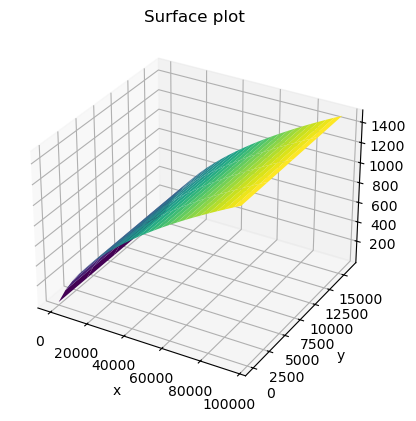

In [4]:
# plot the input geometry
# plot the 2d variable thk with x1 and y1 variables as x and y axes
fig = plt.figure()
ax = plt.axes(projection='3d')
x = ncfile.variables['x1'][:]
y = ncfile.variables['y1'][:]
X, Y = np.meshgrid(x, y)
Z = ncfile.variables['thk'][0][:]
ax.plot_surface(X, Y, Z, rstride=1, cstride=1,
                cmap='viridis', edgecolor='none')
ax.set_title('Surface plot')
# x and y labels
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.show()




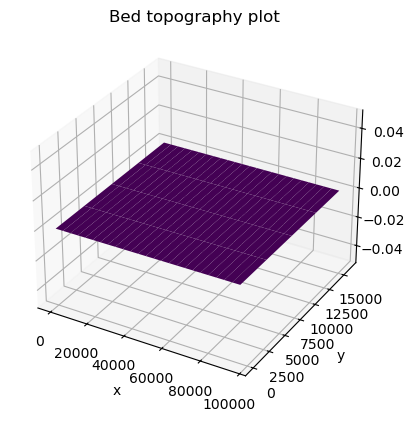

In [5]:
# plot the input geometry
# plot the 2d variable thk with x1 and y1 variables as x and y axes
fig = plt.figure()
ax = plt.axes(projection='3d')
x = ncfile.variables['x1'][:]
y = ncfile.variables['y1'][:]
X, Y = np.meshgrid(x, y)
Z = ncfile.variables['topg'][0][:]
ax.plot_surface(X, Y, Z, rstride=1, cstride=1,
                cmap='viridis', edgecolor='none')
ax.set_title('Bed topography plot')
# x and y labels
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.show()

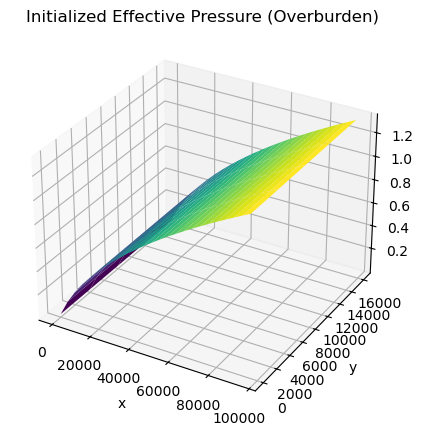

In [6]:
# plot the input geometry
# plot the 2d variable thk with x1 and y1 variables as x and y axes

fig = plt.figure(figsize=(5, 5))
ax = plt.axes(projection='3d')
x = ncfile.variables['x1'][:]
y = ncfile.variables['y1'][:]
X, Y = np.meshgrid(x, y)
Z = ncfile.variables['effecpress'][0][:]
ax.plot_surface(X, Y, Z, rstride=1, cstride=1,
                cmap='viridis', edgecolor='none')
ax.set_title('Initialized Effective Pressure (Overburden)')

ax.set_zlim(Z.min(), Z.max())


# x and y labels
ax.set_xlabel('x')
ax.set_ylabel('y')


plt.show()



In [7]:
# make a comparison of all experiements from run A
# read data
inputfileA = 'SteadyStateA/ESHI.SteadyStateA.out.nc'
inputfileB = 'SteadyStateB/ESHI.SteadyStateB.out.nc'
inputfileC = 'SteadyStateC/ESHI.SteadyStateC.out.nc'
inputfileD = 'SteadyStateD/ESHI.SteadyStateD.out.nc'
inputfileE = 'SteadyStateE/ESHI.SteadyStateE.out.nc'
inputfileF = 'SteadyStateF/ESHI.SteadyStateF.out.nc'


ncfileA = Dataset(inputfileA, 'r')
ncfileB = Dataset(inputfileB, 'r')
ncfileC = Dataset(inputfileC, 'r')
ncfileD = Dataset(inputfileD, 'r')
ncfileE = Dataset(inputfileE, 'r')
ncfileF = Dataset(inputfileF, 'r')

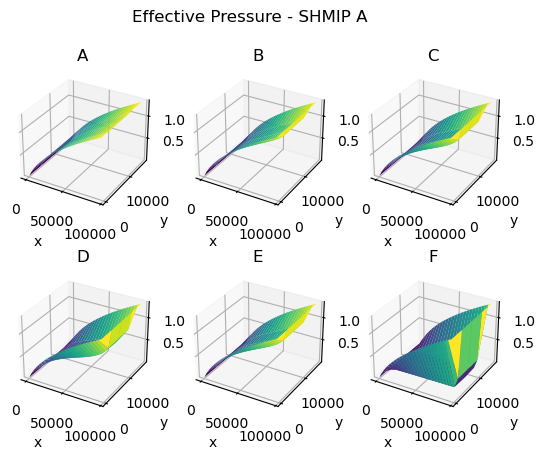

In [8]:
# make a comparison plot

def make_subplot(ax,ncfile,title):
    x = ncfile.variables['x1'][:]
    y = ncfile.variables['y1'][:]
    X, Y = np.meshgrid(x, y)
    Z = ncfile.variables['effecpress'][1][:]
    ax.plot_surface(X, Y, Z, rstride=1, cstride=1,
                    cmap='viridis', edgecolor='none')
    ax.set_title(title)
    # x and y labels
    ax.set_xlabel('x')
    ax.set_ylabel('y')

fig = plt.figure()


ax1 = fig.add_subplot(231, projection='3d')
make_subplot(ax1,ncfileA,'A')

ax2 = fig.add_subplot(232, projection='3d')
make_subplot(ax2,ncfileB,'B')

ax3 = fig.add_subplot(233, projection='3d')
make_subplot(ax3,ncfileC,'C')

ax4 = fig.add_subplot(234, projection='3d')
make_subplot(ax4,ncfileD,'D')

ax5 = fig.add_subplot(235, projection='3d')
make_subplot(ax5,ncfileE,'E')

ax6 = fig.add_subplot(236, projection='3d')
make_subplot(ax6,ncfileF,'F')

plt.suptitle('Effective Pressure - SHMIP A')

plt.show()

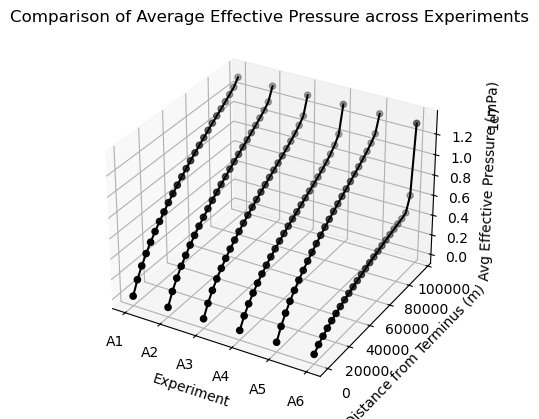

In [9]:
# Function to calculate the average effective pressure for a given ncfile
def calculate_average_effective_pressure(ncfile):
    x = ncfile.variables['x1'][:]  # Distance from the terminus
    
    Z = ncfile.variables['effecpress'][1][:]  # Effective pressure
    # print(Z)
    
    average_Z = np.mean(Z, axis=0)  # Averaging across the y-axis
    
    # variance_Z = np.var(Z, axis=0)  # Variance across the x-axis
    
    average_Z = np.ones((1,len(x))) * average_Z  # Repeat the average_Z to match the shape of y
    # variance_Z = np.ones((1,len(x))) * variance_Z  # Repeat the variance_Z to match the shape of y
    return x, average_Z

# Create figure
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Experiment labels
experiment_labels = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6']
x_experiment = np.arange(len(experiment_labels))  # Numerical representation of experiments


# For each experiment, calculate and plot the average effective pressure
for i, (ncfile, label) in enumerate(zip([ncfileA, ncfileB, ncfileC, ncfileD, ncfileE, ncfileF], experiment_labels)):
    x, average_Z = calculate_average_effective_pressure(ncfile)  # Get y and Z for each experiment
    X, Y = np.meshgrid(x_experiment[i], x)  # Create meshgrid for plotting
    # ax.plot_surface(X, Y, average_Z, rstride=1, cstride=1, cmap='coolwarm', edgecolor='none', label=label)
    ax.scatter(X, Y, average_Z, c='black', label=label)
    ax.plot(X, Y, average_Z.T, c='black')


# Set labels
ax.set_xlabel('Experiment')
ax.set_ylabel('Distance from Terminus (m)')
ax.set_zlabel('Avg Effective Pressure (mPa)')

# Set experiment labels on x-axis
ax.set_xticks(x_experiment)
ax.set_xticklabels(experiment_labels)

plt.title('Comparison of Average Effective Pressure across Experiments')
plt.show()


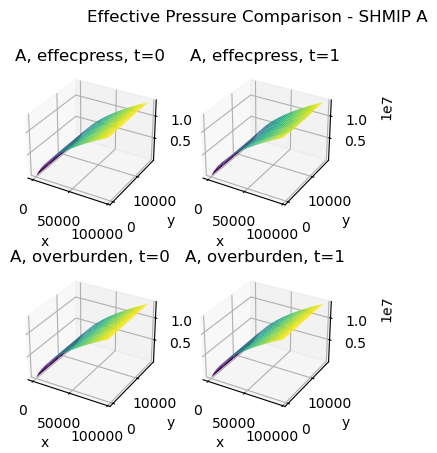

In [10]:
# make a comparison plot

def make_subplot(ax,ncfile,title,var,i):
    x = ncfile.variables['x1'][:]
    y = ncfile.variables['y1'][:]
    X, Y = np.meshgrid(x, y)
    Z = ncfile.variables[var][i][:]
    ax.plot_surface(X, Y, Z, rstride=1, cstride=1,
                    cmap='viridis', edgecolor='none')
    ax.set_title(title)
    # x and y labels
    ax.set_xlabel('x')
    ax.set_ylabel('y')

def make_subplot_overburden(ax,ncfile,title,i):
    x = ncfile.variables['x1'][:]
    y = ncfile.variables['y1'][:]
    X, Y = np.meshgrid(x, y)
    Z = ncfile.variables['thk'][i][:] * 9.81 * 917
    ax.plot_surface(X, Y, Z, rstride=1, cstride=1,
                    cmap='viridis', edgecolor='none')
    ax.set_title(title)
    # x and y labels
    ax.set_xlabel('x')
    ax.set_ylabel('y')

fig = plt.figure()


ax1 = fig.add_subplot(231, projection='3d')
make_subplot(ax1,ncfileA,'A, effecpress, t=0','effecpress',0)

ax2 = fig.add_subplot(232, projection='3d')
make_subplot(ax2,ncfileA,'A, effecpress, t=1','effecpress',1)


ax3 = fig.add_subplot(234, projection='3d')
make_subplot_overburden(ax3,ncfileA,'A, overburden, t=0',0)


ax4 = fig.add_subplot(235, projection='3d')
make_subplot_overburden(ax4,ncfileA,'A, overburden, t=1',1)

plt.suptitle('Effective Pressure Comparison - SHMIP A')

plt.show()

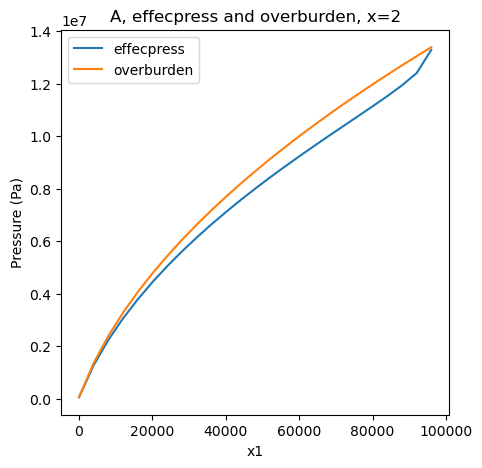

[   53974.62  1357874.8   2391446.2   3274822.2   4059058.5   4771530.
  5428939.    6042369.5   6619618.    7166420.5   7687138.5   8185185.
  8663284.    9123657.    9568141.    9998275.   10415366.   10820533.
 11214742.   11598839.   11973564.   12339570.   12697440.   13047693.
 13390796.  ]
[0.9923664331436157 0.939777672290802 0.9362369179725647
 0.9336360692977905 0.9315656423568726 0.9298502802848816
 0.9283984303474426 0.9271570444107056 0.9260951280593872
 0.9251948595046997 0.924448549747467 0.9238555431365967
 0.9234232902526855 0.9231659770011902 0.9231066703796387
 0.9232790470123291 0.9237305521965027 0.9245290160179138
 0.9257723689079285 0.9276070594787598 0.9302666187286377
 0.9341596364974976 0.9401283264160156 0.9506127238273621
 0.992366373538971]


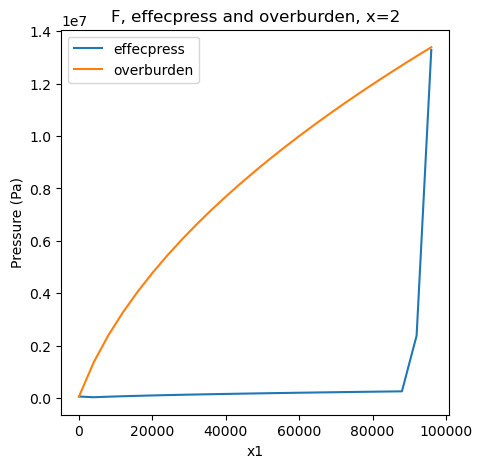

[   53974.62  1357874.8   2391446.2   3274822.2   4059058.5   4771530.
  5428939.    6042369.5   6619618.    7166420.5   7687138.5   8185185.
  8663284.    9123657.    9568141.    9998275.   10415366.   10820533.
 11214742.   11598839.   11973564.   12339570.   12697440.   13047693.
 13390796.  ]
[0.9923664331436157 0.0198473259806633 0.01984732784330845
 0.01984732784330845 0.0198473259806633 0.01984732784330845
 0.01984732784330845 0.01984732784330845 0.01984732784330845
 0.01984732784330845 0.01984732784330845 0.01984732784330845
 0.01984732784330845 0.01984732784330845 0.0198473259806633
 0.0198473259806633 0.0198473259806633 0.01984732784330845
 0.01984732784330845 0.01984732784330845 0.0198473259806633
 0.01984732784330845 0.01984732784330845 0.1823457032442093
 0.992366373538971]


In [11]:
# plot a transect of effecpress and overburden pressure


def make_2d_plot_effecpress(ncfile,title,i):
    plt.figure(figsize=(5,5))
    effecpress = ncfile.variables['effecpress'][1,i]
    plt.plot(ncfile.variables['x1'][:], effecpress, label='effecpress')
    overburden = ncfile.variables['thk'][1,i] * 9.81 * 917
    plt.plot(ncfile.variables['x1'][:], overburden, label='overburden')
    plt.legend()
    plt.xlabel('x1')
    plt.ylabel('Pressure (Pa)')
    plt.title(title)
    plt.show()

    # print(effecpress)
    print(overburden)
    print(effecpress/overburden)

make_2d_plot_effecpress(ncfileA,'A, effecpress and overburden, x=2',2)
make_2d_plot_effecpress(ncfileF,'F, effecpress and overburden, x=2',2)

